# EDA — EEG Motor Movement/Imagery Dataset

Amostra do [eegmmidb (PhysioNet)](https://physionet.org/content/eegmmidb/1.0.0/).
Ficha técnica e instruções: [`../README.md`](../README.md).

## Configuração

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from mne.datasets import eegbci

mne.set_log_level("WARNING")
plt.rcParams["figure.figsize"] = (9, 3.5)

DATA_DIR = Path("..") / "data" / "raw"

In [2]:
# Sujeitos com inconsistências conhecidas (Kim et al., 2024).
PROBLEMATIC_SUBJECTS = [88, 89, 92, 100, 104, 106]

# run -> (tipo de tarefa, o que T1 e T2 significam)
RUN_TASKS = {
    1: ("baseline", "olhos abertos"),
    2: ("baseline", "olhos fechados"),
    3: ("execução", "mão esquerda vs. mão direita"),
    4: ("imagética", "mão esquerda vs. mão direita"),
    5: ("execução", "ambas as mãos vs. ambos os pés"),
    6: ("imagética", "ambas as mãos vs. ambos os pés"),
    7: ("execução", "mão esquerda vs. mão direita"),
    8: ("imagética", "mão esquerda vs. mão direita"),
    9: ("execução", "ambas as mãos vs. ambos os pés"),
    10: ("imagética", "ambas as mãos vs. ambos os pés"),
    11: ("execução", "mão esquerda vs. mão direita"),
    12: ("imagética", "mão esquerda vs. mão direita"),
    13: ("execução", "ambas as mãos vs. ambos os pés"),
    14: ("imagética", "ambas as mãos vs. ambos os pés"),
}


def load_raw(subject, run, data_dir):
    """Carrega uma run de um sujeito a partir de data/raw/ e padroniza os canais."""
    path = Path(data_dir) / f"S{subject:03d}" / f"S{subject:03d}R{run:02d}.edf"
    raw = mne.io.read_raw_edf(path, preload=True)

    # No EDF os canais vêm como "Fc5."; standardize corrige para "FC5".
    eegbci.standardize(raw)
    return raw

## Amostra

In [3]:
REQUESTED_SUBJECTS = [1, 2, 3, 4, 5]
SUBJECTS = [s for s in REQUESTED_SUBJECTS if s not in PROBLEMATIC_SUBJECTS]
RUNS = [1, 3, 4, 8, 12]

print("Sujeitos:", SUBJECTS)
for run in RUNS:
    print(f"  R{run:02d}  {RUN_TASKS[run]}")

Sujeitos: [1, 2, 3, 4, 5]
  R01  ('baseline', 'olhos abertos')
  R03  ('execução', 'mão esquerda vs. mão direita')
  R04  ('imagética', 'mão esquerda vs. mão direita')
  R08  ('imagética', 'mão esquerda vs. mão direita')
  R12  ('imagética', 'mão esquerda vs. mão direita')


## Carregamento

In [4]:
raws = {}
summary_rows = []

for subject in SUBJECTS:
    for run in RUNS:
        raw = load_raw(subject, run, DATA_DIR)
        raws[(subject, run)] = raw

        events, event_id = mne.events_from_annotations(raw)
        counts = {str(name): int((events[:, 2] == code).sum())
                  for name, code in event_id.items()}
        task, description = RUN_TASKS[run]
        summary_rows.append({
            "subject": f"S{subject:03d}",
            "run": f"R{run:02d}",
            "task_type": task,
            "description": description,
            "sfreq_hz": raw.info["sfreq"],
            "n_channels": len(raw.ch_names),
            "duration_s": round(raw.n_times / raw.info["sfreq"], 1),
            "n_events_total": len(events),
            **{f"n_{name}": n for name, n in counts.items()},
        })

print(len(raws), "registros carregados")

25 registros carregados


## Estrutura e cobertura

In [5]:
example_raw = raws[(SUBJECTS[0], 4)]
data = example_raw.get_data()
events, event_id = mne.events_from_annotations(example_raw)

print("Canais:", example_raw.ch_names)
print("dtype:", data.dtype, "(Volts)")
print(f"Amplitude: {data.min()*1e6:.1f} a {data.max()*1e6:.1f} uV | σ {data.std()*1e6:.1f} uV")
print("NaN:", bool(np.isnan(data).any()))
print("Eventos:", {str(k): v for k, v in event_id.items()}, "| total:", len(events))

Canais: ['FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'Fp1', 'Fpz', 'Fp2', 'AF7', 'AF3', 'AFz', 'AF4', 'AF8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FT8', 'T7', 'T8', 'T9', 'T10', 'TP7', 'TP8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'O1', 'Oz', 'O2', 'Iz']
dtype: float64 (Volts)
Amplitude: -376.0 a 595.0 uV | σ 53.5 uV
NaN: False
Eventos: {'T0': 1, 'T1': 2, 'T2': 3} | total: 30


In [6]:
df_summary = pd.DataFrame(summary_rows)
df_summary

,subject,run,task_type,description,sfreq_hz,n_channels,duration_s,n_events_total,n_T0,n_T1,n_T2
0,S001,R01,baseline,olhos abertos,160.0,64,61.0,1,1,NaN,NaN
1,S001,R03,execução,mão esquerda vs. mão direita,160.0,64,125.0,30,15,8.0,7.0
2,S001,R04,imagética,mão esquerda vs. mão direita,160.0,64,125.0,30,15,8.0,7.0
3,S001,R08,imagética,mão esquerda vs. mão direita,160.0,64,125.0,30,15,8.0,7.0
4,S001,R12,imagética,mão esquerda vs. mão direita,160.0,64,125.0,30,15,7.0,8.0
5,S002,R01,baseline,olhos abertos,160.0,64,61.0,1,1,NaN,NaN
6,S002,R03,execução,mão esquerda vs. mão direita,160.0,64,123.0,30,15,8.0,7.0
7,S002,R04,imagética,mão esquerda vs. mão direita,160.0,64,123.0,30,15,7.0,8.0
8,S002,R08,imagética,mão esquerda vs. mão direita,160.0,64,123.0,30,15,8.0,7.0
9,S002,R12,imagética,mão esquerda vs. mão direita,160.0,64,123.0,30,15,8.0,7.0


Sujeitos: 5
Tarefas: ['baseline', 'execução', 'imagética']
Duração total (min): 46.4


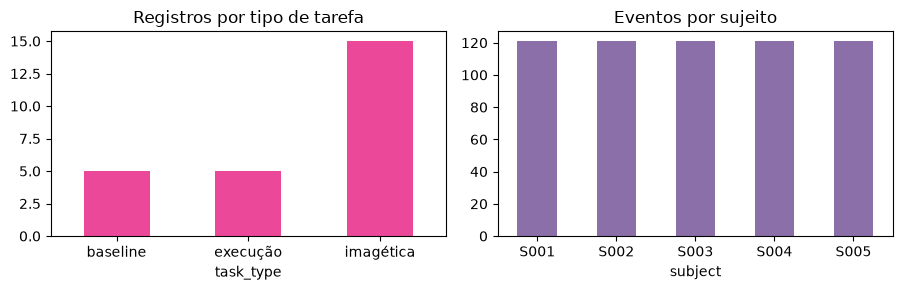

In [7]:
print("Sujeitos:", df_summary["subject"].nunique())
print("Tarefas:", df_summary["task_type"].unique().tolist())
print("Duração total (min):", round(df_summary["duration_s"].sum() / 60, 1))

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
df_summary.groupby("task_type").size().plot(kind="bar", ax=axes[0], color="#ec4899")
axes[0].set_title("Registros por tipo de tarefa")
axes[0].tick_params(axis="x", rotation=0)

df_summary.groupby("subject")["n_events_total"].sum().plot(
    kind="bar", ax=axes[1], color="#8a6fa8")
axes[1].set_title("Eventos por sujeito")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## Distribuição das classes

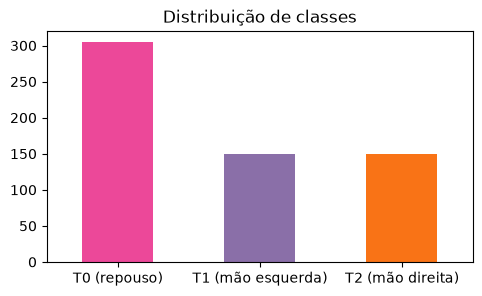

T0 (repouso)         305.0
T1 (mão esquerda)    150.0
T2 (mão direita)     150.0
dtype: float64
Razão T1/T2 = 1.00


In [8]:
event_totals = df_summary[[c for c in df_summary.columns if c.startswith("n_T")]].sum()
event_totals.index = ["T0 (repouso)", "T1 (mão esquerda)", "T2 (mão direita)"]

event_totals.plot(kind="bar", color=["#ec4899", "#8a6fa8", "#f97316"],
                  title="Distribuição de classes", rot=0, figsize=(5.5, 3))
plt.show()

print(event_totals)
print(f"Razão T1/T2 = {event_totals.iloc[1] / event_totals.iloc[2]:.2f}")

## Sinal bruto

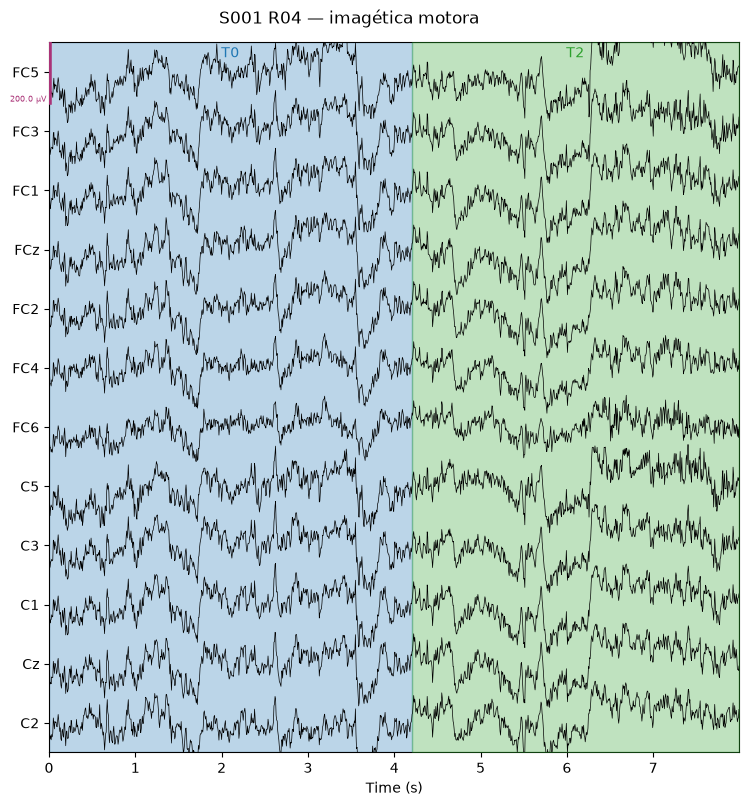

In [9]:
fig = example_raw.plot(duration=8, n_channels=12, scalings=dict(eeg=100e-6),
                       show=False, show_scrollbars=False)
fig.suptitle(f"S{SUBJECTS[0]:03d} R04 — imagética motora", y=1.01)
plt.show()